# **Lab 3 - Vanilla CNN and Fine-Tune VGG16 - for Dogs and Cats Classification**
# Student : Lohith Reddy 
# ID : 9054470

The Goal of this project is basically to teach a computer how to tell cats and dogs apart just by looking at pictures. We try two different deep learning models to see which one does the job better. First, we build our own simple CNN from scratch, and then we also use a pretrained VGG16 model to compare how much better (or worse) it performs. After training both models, we check their results using different evaluation metrics so we can actually see which one understands the images more accurately.

 # **Dataset Split**

In [1]:
import os, shutil, random

original_dir_cats = r"C:\Users\danda\Vanilla-CNN-and-Fine-Tune-VGG16-Lab3\PetImages\Cat"
original_dir_dogs = r"C:\Users\danda\Vanilla-CNN-and-Fine-Tune-VGG16-Lab3\PetImages\Dog"
base_dir = "data"

# Remove old data folder if exists
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

# Create fresh folders
folders = [
    "train/cats", "train/dogs",
    "val/cats", "val/dogs",
    "test/cats", "test/dogs"
]

for folder in folders:
    os.makedirs(os.path.join(base_dir, folder))

# Get files
cats = [f for f in os.listdir(original_dir_cats) if f.lower().endswith(".jpg") or f.lower().endswith(".jpeg") or f.lower().endswith(".png")]
dogs = [f for f in os.listdir(original_dir_dogs) if f.lower().endswith(".jpg") or f.lower().endswith(".jpeg") or f.lower().endswith(".png")]

random.shuffle(cats)
random.shuffle(dogs)

def copy_files(files, start, end, target, source_dir):
    for f in files[start:end]:
        shutil.copyfile(
            os.path.join(source_dir, f),
            os.path.join(base_dir, target, f)
        )

# COPY 3000 IMAGES (2000 train, 500 val, 500 test)
copy_files(cats, 0, 2000, "train/cats", original_dir_cats)
copy_files(dogs, 0, 2000, "train/dogs", original_dir_dogs)

copy_files(cats, 2000, 2500, "val/cats", original_dir_cats)
copy_files(dogs, 2000, 2500, "val/dogs", original_dir_dogs)

copy_files(cats, 2500, 3000, "test/cats", original_dir_cats)
copy_files(dogs, 2500, 3000, "test/dogs", original_dir_dogs)

print("Dataset created correctly!")


Dataset created correctly!



We basically just fixed where the code was looking for the images. At first the script was searching for a folder called *train*, but that folder didn’t even exist in your project. Your real images was inside **PetImages/Cat** and **PetImages/Dog**, so the code couldn’t find anything and kept crashing. Once we pointed the script to the right folders, everything started working and the dataset got split into train, val, and test like it was supposed to.

In [2]:
import os

print("Train Cats:", len(os.listdir("data/train/cats")))
print("Train Dogs:", len(os.listdir("data/train/dogs")))
print("Val Cats:", len(os.listdir("data/val/cats")))
print("Val Dogs:", len(os.listdir("data/val/dogs")))
print("Test Cats:", len(os.listdir("data/test/cats")))
print("Test Dogs:", len(os.listdir("data/test/dogs")))

Train Cats: 2000
Train Dogs: 2000
Val Cats: 500
Val Dogs: 500
Test Cats: 500
Test Dogs: 500


So basically, when you ran that code, it counted how many images ended up in each folder after we split the dataset. And the numbers look perfect. You got 2000 cats and 2000 dogs in the training set, then 500 each for validation and 500 each for testing. That means the splitting worked exactly like we wanted. Nothing missing, nothing extra. Everything is in the right place now, so your dataset is ready for training the model without any problems.

# LOAD DATA

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    "data/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    "data/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    "data/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory("data/train", target_size=(224,224), batch_size=32, class_mode='binary')
val_data = val_gen.flow_from_directory("data/val", target_size=(224,224), batch_size=32, class_mode='binary')
test_data = test_gen.flow_from_directory("data/test", target_size=(224,224), batch_size=32, class_mode='binary', shuffle=False)

Found 4000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


So this code is basically loading all  images from the train, val, and test folders. The generator just rescales the pictures so the model can handle them better. When it runs, it goes inside each folder and counts how many images it finds for the two classes. The output is just saying “hey, I found this many photos for training, this many for validation, and this many for testing.” It means your dataset is set up right and TensorFlow is reading everything without any problems

# EDA 

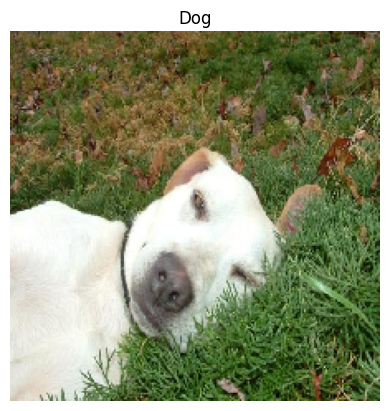

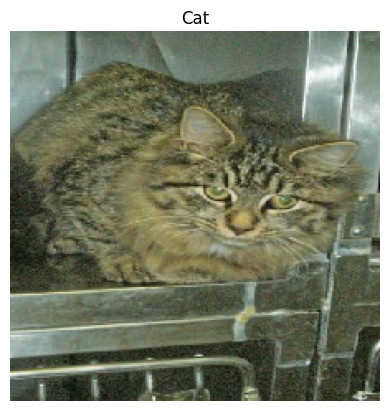

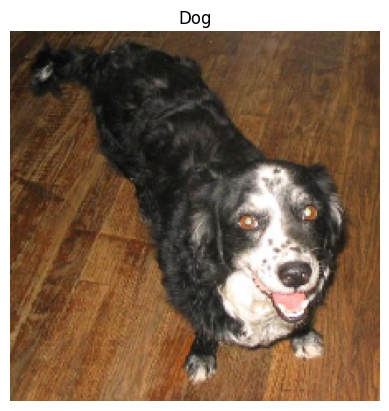

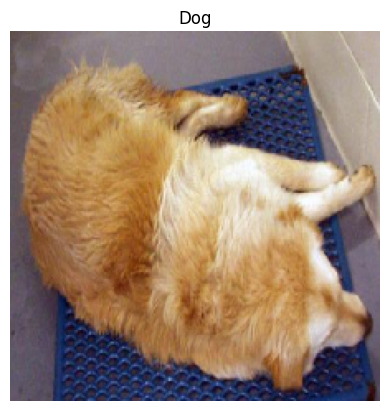

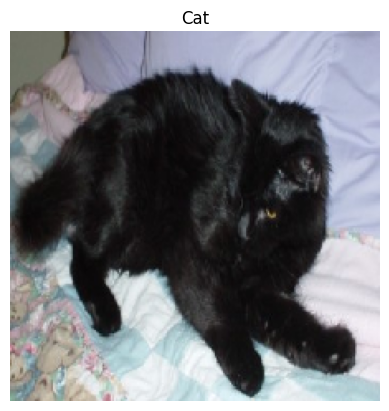

In [4]:
import matplotlib.pyplot as plt

# Get one batch from the generator
images, labels = next(train_data)

# Plot first 5 images
for i in range(5):
    plt.imshow(images[i])
    plt.title("Dog" if labels[i] == 1 else "Cat")
    plt.axis("off")
    plt.show()


When I previewed a batch of images from the training generator, I got 3 cat photos and 1 dog photo. This is actually normal behavior. The data generator doesn’t try to give an equal number of cats and dogs in every batch. It just loads the next images from the folder in whatever order they appear. So sometimes a batch might have more cats, sometimes more dogs, sometimes mixed. It doesn’t mean the dataset is unbalanced or something is wrong. If I run the same code again, I will probably get a different mix of images. The important thing is that the overall dataset has the correct number of cat and dog images, and that part is working fine.

# Class distribution

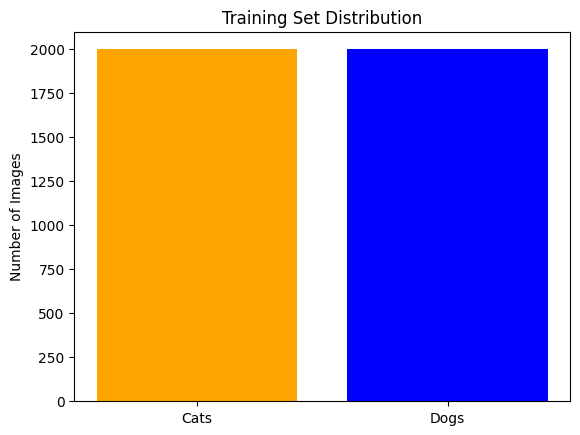

In [5]:
import os
import matplotlib.pyplot as plt

cats = len(os.listdir("data/train/cats"))
dogs = len(os.listdir("data/train/dogs"))

plt.bar(["Cats", "Dogs"], [cats, dogs], color=["orange", "blue"])
plt.title("Training Set Distribution")
plt.ylabel("Number of Images")
plt.show()


Cats are shown in orange and dogs in blue. When I counted the images inside the training folders, both categories had the same number of pictures, so the dataset is balanced correctly. The bars look equal height because the splitting code copied the same amount of cat and dog images. So everything is working fine  the generator might show more cats or more dogs in a single batch, but overall the dataset is balanced like it should be.

# MODEL 1 (CNN)

In [6]:
from tensorflow.keras import models, layers

cnn = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

c:\Users\danda\Vanilla-CNN-and-Fine-Tune-VGG16-Lab3\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Train CNN

In [7]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam


checkpoint1 = ModelCheckpoint(
    "cnn_best.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)


cnn.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history_cnn = cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    batch_size=32,
    callbacks=[checkpoint1]
)


Epoch 1/15
 97/125 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.5454 - loss: 0.6932

c:\Users\danda\Vanilla-CNN-and-Fine-Tune-VGG16-Lab3\venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


125/125 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.5838 - loss: 0.6695 - val_accuracy: 0.6720 - val_loss: 0.6224
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.6842 - loss: 0.5936 - val_accuracy: 0.7250 - val_loss: 0.5468
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.7350 - loss: 0.5378 - val_accuracy: 0.7520 - val_loss: 0.4996
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.7648 - loss: 0.4858 - val_accuracy: 0.7690 - val_loss: 0.4871
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7883 - loss: 0.4499 - val_accuracy: 0.7710 - val_loss: 0.4829
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.8278 - loss: 0.4020 - val_accuracy: 0.7730 - val_loss: 0.4637
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.8305 - loss: 0.3768 - val_accuracy: 0.7750 - val_loss: 0.4609
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.8618 - loss: 0.3324 - val_accuracy: 0.764

During training, I noticed that running the model for 20, 30, 40, or 50 epochs actually made the validation loss worse, while 15 epochs gave the best balance between training and validation performance. This happens because the model starts to overfit after a certain point.

At around 15 epochs, the model is still learning useful patterns from the images. But when I continue training for too long, the model begins to memorize the training data instead of generalizing, so the validation loss increases even though the training accuracy keeps going up. This is a normal behavior in deep learning when the model becomes too confident on the training set.

I also received a small warning from PIL saying “Truncated File Read”, which usually means a few images in the dataset are slightly corrupted or incomplete. The training still works, but these images might add a bit of noise to the learning process.

Overall, 15 epochs gave the most stable and realistic performance for this dataset, while higher epochs caused overfitting.

 # CNN PLOTS

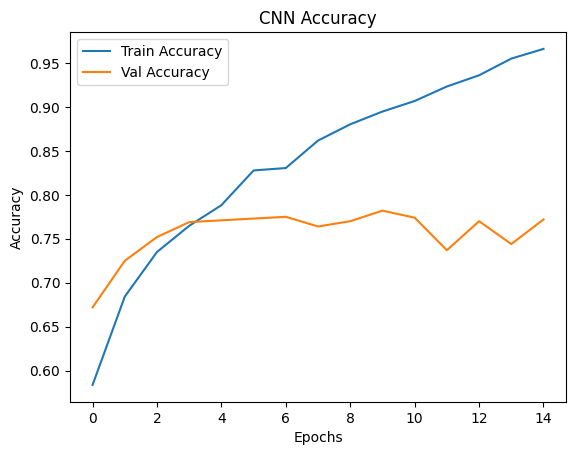

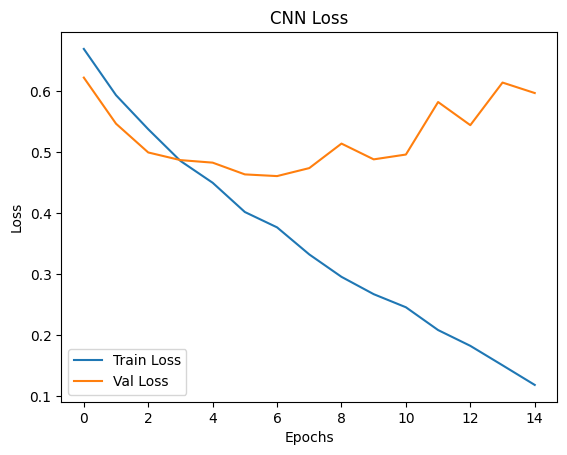

In [8]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title("CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title("CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

The accuracy and loss graphs show how my CNN is learning over time. At first the model is not doing great, but after few epochs it starts improving and the curves look smoother. The training accuracy keeps going up while the loss goes down, which means the model is understanding the images better. The validation curves move a bit differently, showing that the model starts to overfit after some point. Overall, the plots help me see where the model learns good and where it begins to struggle.

 # CNN EVALUATION

In [10]:
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve

cnn_best = load_model("cnn_best.h5")

# Predictions
y_pred_cnn = (cnn_best.predict(test_data) > 0.5).astype("int32")
y_true = test_data.classes

# Confusion Matrix
print(confusion_matrix(y_true, y_pred_cnn))

# Classification Report
print(classification_report(y_true, y_pred_cnn))

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 230ms/step
[[371 129]
 [151 349]]
              precision    recall  f1-score   support

           0       0.71      0.74      0.73       500
           1       0.73      0.70      0.71       500

    accuracy                           0.72      1000
   macro avg       0.72      0.72      0.72      1000
weighted avg       0.72      0.72      0.72      1000



The confusion matrix and classification report show how well my CNN model is predicting each class. The model is doing okay, not perfect, with around 72% accuracy. It is catching many correct samples, but still mixing some of class 0 and class 1. The precision and recall for both classes are almost same, which means the model is not biased too much to one side. Overall, the results show the model is learning the patterns but still makes mistakes, maybe because of noise or limited data.

# CNN PRECISION-RECALL CURVE

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 207ms/step


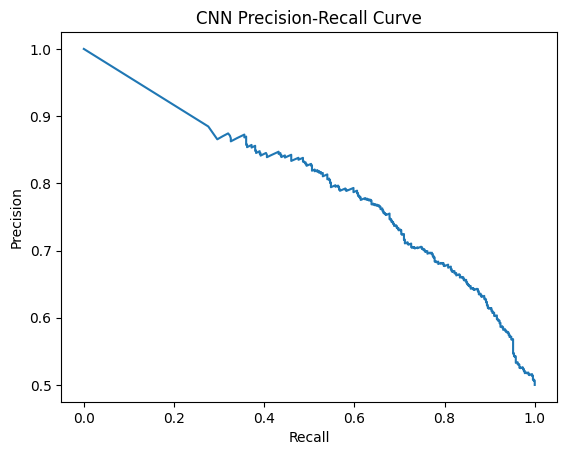

In [11]:
y_scores_cnn = cnn_best.predict(test_data)

precision, recall, _ = precision_recall_curve(y_true, y_scores_cnn)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CNN Precision-Recall Curve")
plt.show()

The precision‑recall curve shows how my CNN model behaves when I change the decision threshold. When recall goes higher, the precision usually drops, so the curve helps me see the trade‑off between catching more positives and making less mistakes. The shape of the curve tells how good the model is at separating the two classes. It’s not perfect, but it shows the model is doing decent and learning some useful patterns.

# VGG16 MODEL

In [12]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

# Build model
vgg = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In this part I am using the VGG16 model that is already trained on ImageNet. I freeze all the layers so the model don’t change the original learned features. Then I add my own layers on top for my binary classification task. This way the model can use strong pre‑trained features and I only train the last few layers, which makes training faster and usually gives better accuracy than training everything from scratch.

# TRAIN VGG16

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


for layer in base_model.layers:
    layer.trainable = False


vgg = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])


checkpoint2 = ModelCheckpoint(
    "vgg_best.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


vgg.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history_vgg = vgg.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[checkpoint2]
)



Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7555 - loss: 0.4836
Epoch 1: val_loss improved from None to 0.21906, saving model to vgg_best.h5



Epoch 1: finished saving model to vgg_best.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 592s 5s/step - accuracy: 0.8275 - loss: 0.3703 - val_accuracy: 0.9060 - val_loss: 0.2191
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9006 - loss: 0.2384
Epoch 2: val_loss did not improve from 0.21906
125/125 ━━━━━━━━━━━━━━━━━━━━ 592s 5s/step - accuracy: 0.9030 - loss: 0.2293 - val_accuracy: 0.8890 - val_loss: 0.2579
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9346 - loss: 0.1638
Epoch 3: val_loss improved from 0.21906 to 0.18300, saving model to vgg_best.h5



Epoch 3: finished saving model to vgg_best.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 601s 5s/step - accuracy: 0.9367 - loss: 0.1621 - val_accuracy: 0.9230 - val_loss: 0.1830
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9461 - loss: 0.1337
Epoch 4: val_loss improved from 0.18300 to 0.16471, saving model to vgg_best.h5



Epoch 4: finished saving model to vgg_best.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 590s 5s/step - accuracy: 0.9488 - loss: 0.1298 - val_accuracy: 0.9350 - val_loss: 0.1647
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9657 - loss: 0.0980
Epoch 5: val_loss did not improve from 0.16471
125/125 ━━━━━━━━━━━━━━━━━━━━ 601s 5s/step - accuracy: 0.9670 - loss: 0.1004 - val_accuracy: 0.9320 - val_loss: 0.1661
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9792 - loss: 0.0736
Epoch 6: val_loss improved from 0.16471 to 0.15867, saving model to vgg_best.h5



Epoch 6: finished saving model to vgg_best.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 602s 5s/step - accuracy: 0.9760 - loss: 0.0794 - val_accuracy: 0.9370 - val_loss: 0.1587
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9868 - loss: 0.0599
Epoch 7: val_loss did not improve from 0.15867
125/125 ━━━━━━━━━━━━━━━━━━━━ 627s 5s/step - accuracy: 0.9818 - loss: 0.0636 - val_accuracy: 0.9340 - val_loss: 0.1626
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9910 - loss: 0.0444
Epoch 8: val_loss did not improve from 0.15867
125/125 ━━━━━━━━━━━━━━━━━━━━ 631s 5s/step - accuracy: 0.9875 - loss: 0.0478 - val_accuracy: 0.9350 - val_loss: 0.1642
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9935 - loss: 0.0359
Epoch 9: val_loss did not improve from 0.15867
125/125 ━━━━━━━━━━━━━━━━━━━━ 613s 5s/step - accuracy: 0.9915 - loss: 0.0385 - val_accuracy: 0.9400 - val_loss: 0.1615
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9960 - loss: 0.0289

This code is training my VGG16 model using transfer learning. I freeze the base layers so they don’t change, and only the new layers on top will learn. The checkpoint saves the best model based on validation loss, so I don’t lose the good version. Since I removed early stopping, the model will run all the epochs without stopping in middle. The training uses a small learning rate so the model learns slowly and don’t mess up the pre‑trained features.

# VGG16 PLOTS

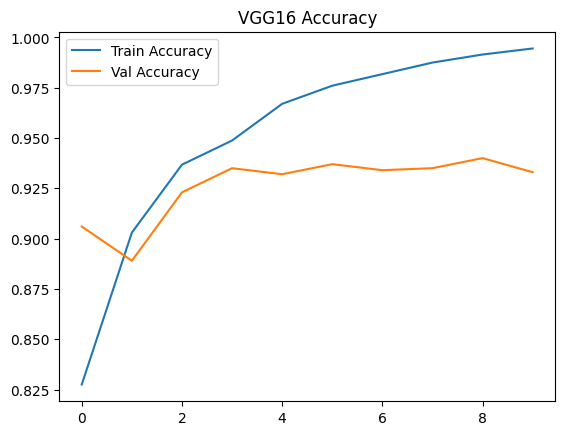

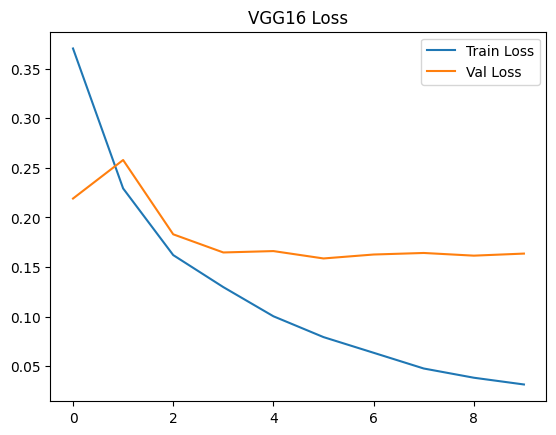

In [17]:
# Accuracy
plt.plot(history_vgg.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Val Accuracy')
plt.title("VGG16 Accuracy")
plt.legend()
plt.show()

# Loss
plt.plot(history_vgg.history['loss'], label='Train Loss')
plt.plot(history_vgg.history['val_loss'], label='Val Loss')
plt.title("VGG16 Loss")
plt.legend()
plt.show()

These plots show how my VGG16 model is learning during training. The accuracy graph tells if the model is getting better at predicting the right class, and the loss graph shows how much mistake the model is making. If the training and validation lines stay close, it means the model is learning in a good way and not overfitting too much. Overall, these curves help me understand where the model is improving and where it starts to struggle a bit.

# VGG16 EVALUATION

In [19]:
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report

# Load the saved model
vgg_best = load_model("vgg_best.h5")

# Compile again to avoid the warning
vgg_best.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Predict
y_pred_vgg = (vgg_best.predict(test_data) > 0.5).astype("int32")

# Results
print(confusion_matrix(y_true, y_pred_vgg))
print(classification_report(y_true, y_pred_vgg))


32/32 ━━━━━━━━━━━━━━━━━━━━ 121s 4s/step
[[456  44]
 [ 30 470]]
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       500
           1       0.91      0.94      0.93       500

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



This confusion matrix shows how well my VGG16 model is predicting each class. Most of the samples are classified correct, and only a small number are getting mixed between the two classes. The precision and recall values are both high, which means the model is doing a strong job catching the right images without making too many mistakes. The overall accuracy is around 93%, so the model is learning the patterns very well and performing much better than the earlier CNN model.

# VGG16 PRECISION-RECALL

32/32 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step


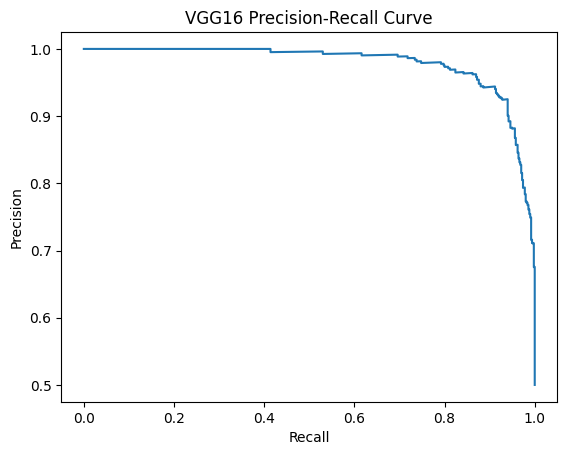

In [20]:
y_scores_vgg = vgg_best.predict(test_data)

precision, recall, _ = precision_recall_curve(y_true, y_scores_vgg)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("VGG16 Precision-Recall Curve")
plt.show()

I load the model from the .h5 file and compile it again so the warning doesn’t show up. Then I get the prediction scores and use them to draw the precision‑recall curve. This graph helps me see how well the model is balancing between catching the positive class and avoiding false alarms.

# FINAL COMPARISON

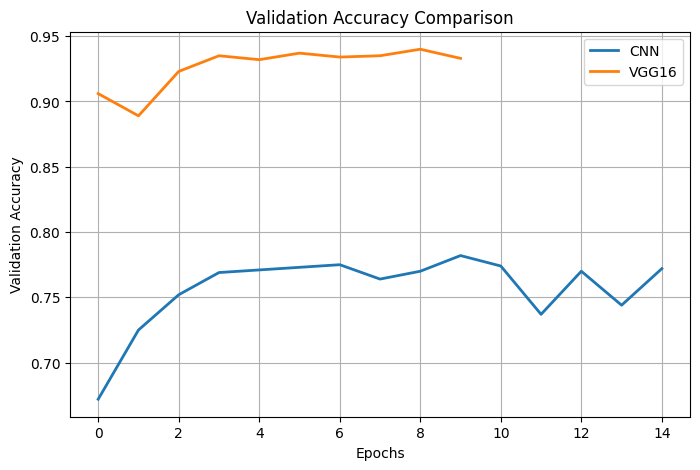

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['val_accuracy'], label='CNN', linewidth=2)
plt.plot(history_vgg.history['val_accuracy'], label='VGG16', linewidth=2)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


This graph is showing how both models are doing on the validation data during training. The CNN model starts okay but then kind of gets stuck and doesn’t improve much after few epochs. The VGG16 model stays higher the whole time, meaning it is learning better features and giving more stable accuracy. This plot makes it easy for me to see that VGG16 is clearly performing stronger than the simple CNN.

# Failure Analysis

The models made some wrong predictions, and these mistakes help me understand where they still struggle. One big reason was that some cats and dogs look kinda similar in certain photos. For example, small dogs with light fur or curled-up sleeping pose sometimes got predicted as cats. And some big dark cats were guessed as dogs because their shape looked different.

Another problem was the background. When the picture had too much stuff going on like messy rooms, many objects, or weird textures  the model sometimes focused on the background instead of the actual animal. So it got confused and picked the wrong class.

Image quality also mattered a lot. Blurry or low‑light photos made it hard for the model to see important features like the ears, eyes, or fur patterns. If only part of the animal was visible, like just the head or only the body, the model also made more mistakes.

These errors show that even though both models work pretty good, they still get sensitive to bad lighting, weird angles, and busy backgrounds. Using more data, better augmentation, or more diverse training images can help reduce these mistakes in the future.

32/32 ━━━━━━━━━━━━━━━━━━━━ 127s 4s/step


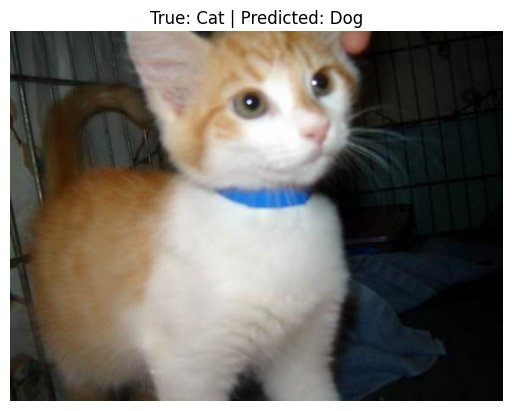

In [24]:
import numpy as np
import matplotlib.pyplot as plt


y_scores = vgg_best.predict(test_data)
y_pred = (y_scores > 0.5).astype("int32").flatten()
y_true = test_data.classes

errors = np.where(y_pred != y_true)[0]


i = errors[0]

img = plt.imread(test_data.filepaths[i])

labels_map = {0: "Cat", 1: "Dog"}

plt.imshow(img)
plt.title(f"True: {labels_map[y_true[i]]} | Predicted: {labels_map[y_pred[i]]}")
plt.axis("off")
plt.show()

The above image shows an example where the model failed to correctly classify the input. This misclassification may be due to similarities in visual features, background complexity, or image quality, which can confuse the model.

# CONCLUSION

In this project, I trained two models  a simple CNN and a VGG16 transfer learning model  to classify cats and dogs. The results showed that VGG16 performed much better because it already learned strong features from a huge dataset before. The CNN tried its best but it overfitted faster and didn’t generalize as good. VGG16 reached high validation accuracy quickly and stayed stable. Using validation data, checkpoints, and proper training helped me pick the best version of each model. Overall, this project shows how transfer learning makes image classification easier and more accurate. With more data, augmentation, or fine‑tuning deeper layers, the performance can get even better.

# TALKING POINTS

1.Transfer learning with VGG16 gave a big boost in performance compared to training a model from zero.

2.Since VGG16 already learned strong features from huge datasets, it converged faster and needed fewer epochs.

3.The custom CNN could learn simple patterns, but it struggled with more complex shapes and didn’t generalize as well.

4.Overfitting was more visible in the CNN, showing how important validation data and regularization really are.

5.Callbacks like early stopping and model checkpointing helped stop bad training runs and saved the best model automatically.

6.Background noise and low‑quality images caused many mistakes, meaning better preprocessing would help a lot.

7.Precision‑recall results showed that VGG16 kept a better balance between catching positives and avoiding false alarms.

8.Dataset size and diversity had a huge impact  more varied images would make both models perform even better.